# BANK LOAN ANALYSIS REPORT


### This project analyzes bank loan data to understand customer financial behavior, loan distribution patterns, and potential risk indicators. The insights can help banks improve lending decisions and risk management

### Importing the Liabraies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Importing the Data 

In [2]:
df = pd.read_excel('Bank Loan Data.xlsx')

In [3]:
df.head()

,id,State,application_type,Borrower_length,Age,Gender,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,Purpose,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,481733,PB,Individual,2 years,60.0,Female,MORTGAGE,2021-10-02 00:00:00,2/13/2021,2/13/2021,...,moving,36 months,Not Verified,51000.0,0.1068,218.97,0.0788,"$7,000",19,"$7,883"
1,839052,HR,Individual,4 years,32.0,Female,MORTGAGE,2021-11-08 00:00:00,11/14/2021,8/14/2021,...,moving,36 months,Not Verified,128000.0,0.0784,161.71,0.1299,"$4,800",22,"$5,821"
2,476667,MH,Individual,< 1 year,35.0,Female,MORTGAGE,2021-10-01 00:00:00,4/15/2021,3/13/2021,...,moving,36 months,Not Verified,150000.0,0.0370,856.18,0.1704,"$24,000",16,"$30,892"
3,821321,MH,Individual,4 years,32.0,Female,RENT,2021-11-07 00:00:00,4/14/2021,8/13/2021,...,moving,36 months,Not Verified,61000.0,0.0696,165.91,0.1479,"$4,800",15,"$5,837"
4,587985,WB,Individual,7 years,32.0,Female,MORTGAGE,2021-10-09 00:00:00,9/13/2021,4/13/2021,...,moving,36 months,Source Verified,86700.0,0.1839,164.86,0.1149,"$5,000",42,"$5,001"


## Understanding The Data

### Summary: This step provides a high-level understanding of the dataset structure. It checks the number of rows and columns, data types, and missing values. This helps identify data quality issues early in the analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   State                  38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   Borrower_length        38576 non-null  object 
 4   Age                    35444 non-null  float64
 5   Gender                 36408 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  Good vs Bad Loan       38576 non-null  object 
 12  next_payment_date      38576 non-null  object 
 13  member_id              38576 non-null  int64  
 14  Purpose                38576 non-null  object 
 15  te

In [5]:
df.columns

Index(['id', 'State', 'application_type', 'Borrower_length', 'Age', 'Gender',
       'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'Good vs Bad Loan',
       'next_payment_date', 'member_id', 'Purpose', 'term',
       'verification_status', 'annual_income', 'dti', 'installment',
       'int_rate', ' loan_amount ', 'total_acc', ' total_payment '],
      dtype='object')

In [6]:
df.describe()

,id,Age,member_id,annual_income,dti,installment,int_rate,total_acc
count,3.857600e+04,35444.00000,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,35.67230,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,22.132544
std,2.113246e+05,7.73399,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,11.392282
min,5.473400e+04,21.00000,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,2.000000
25%,5.135170e+05,31.00000,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,14.000000
50%,6.627280e+05,35.00000,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,20.000000
75%,8.365060e+05,39.00000,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,29.000000
max,1.077501e+06,65.00000,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,90.000000


In [7]:
df.isna().sum()

id                          0
State                       0
application_type            0
Borrower_length             0
Age                      3132
Gender                   2168
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
Good vs Bad Loan            0
next_payment_date           0
member_id                   0
Purpose                     0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
 loan_amount                0
total_acc                   0
 total_payment              0
dtype: int64

# Data Cleaning

## Summary

#### In this step, the columns were cleaned by:
#### 1. Identifying total missing values using different charts and understanding whether the values represent outliers or not. Based on the insights obtained from the visualizations, missing values were filled using appropriate statistical measures.
#### 2. Observing that several columns contained improperly formatted column names. In this step, all column names were standardized and converted into a proper and consistent format.
#### 3. Removing currency symbols from selected columns and converting those columns into numeric data types to ensure accurate calculations and analysis.
### Overall, the data cleaning process ensures accurate, consistent, and reliable results for further analysis.

<Axes: ylabel='Age'>

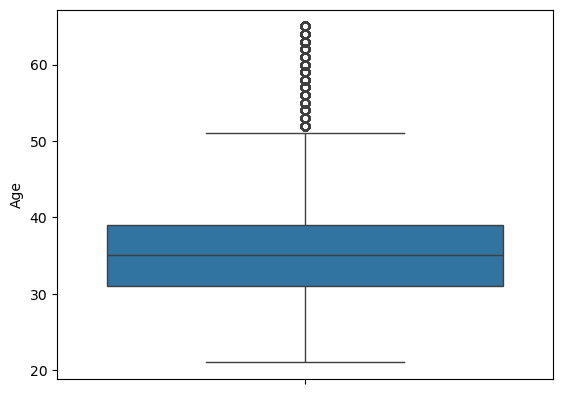

In [8]:
sns.boxplot(df['Age'])

In [9]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')



In [10]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\sanja\AppData\Local\Temp\ipykernel_2524\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [11]:
df.isna().sum()

id                          0
State                       0
application_type            0
Borrower_length             0
Age                         0
Gender                   2168
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
Good vs Bad Loan            0
next_payment_date           0
member_id                   0
Purpose                     0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
 loan_amount                0
total_acc                   0
 total_payment              0
dtype: int64

#### Filling the Null Values in the Columns of Gender

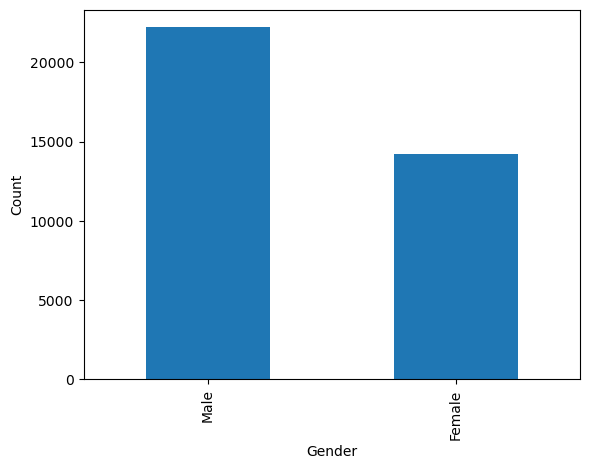

In [12]:
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


In [13]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True) 

C:\Users\sanja\AppData\Local\Temp\ipykernel_2524\3367507956.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [14]:
df.isna().sum()

id                       0
State                    0
application_type         0
Borrower_length          0
Age                      0
Gender                   0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
Good vs Bad Loan         0
next_payment_date        0
member_id                0
Purpose                  0
term                     0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
 loan_amount             0
total_acc                0
 total_payment           0
dtype: int64

In [15]:
df.columns

Index(['id', 'State', 'application_type', 'Borrower_length', 'Age', 'Gender',
       'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'Good vs Bad Loan',
       'next_payment_date', 'member_id', 'Purpose', 'term',
       'verification_status', 'annual_income', 'dti', 'installment',
       'int_rate', ' loan_amount ', 'total_acc', ' total_payment '],
      dtype='object')

#### Renaming the Columns name

In [16]:
df.rename(columns={' loan_amount ':'loan_amount'}, inplace=True)

In [17]:
df.rename(columns={' total_payment ':'Total Payment'}, inplace=True)

In [18]:
df.rename(columns={'Borrower_length':'Borrower Year'}, inplace=True)

In [19]:
df.columns

Index(['id', 'State', 'application_type', 'Borrower Year', 'Age', 'Gender',
       'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'Good vs Bad Loan',
       'next_payment_date', 'member_id', 'Purpose', 'term',
       'verification_status', 'annual_income', 'dti', 'installment',
       'int_rate', 'loan_amount', 'total_acc', 'Total Payment'],
      dtype='object')

In [20]:
df['installment'].unique()

array([218.97, 161.71, 856.18, ..., 164.99, 113.5 , 627.93])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   State                  38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   Borrower Year          38576 non-null  object 
 4   Age                    38576 non-null  float64
 5   Gender                 38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  Good vs Bad Loan       38576 non-null  object 
 12  next_payment_date      38576 non-null  object 
 13  member_id              38576 non-null  int64  
 14  Purpose                38576 non-null  object 
 15  te

In [22]:
df.head(2)

,id,State,application_type,Borrower Year,Age,Gender,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,Purpose,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,Total Payment
0,481733,PB,Individual,2 years,60.0,Female,MORTGAGE,2021-10-02 00:00:00,2/13/2021,2/13/2021,...,moving,36 months,Not Verified,51000.0,0.1068,218.97,0.0788,"$7,000",19,"$7,883"
1,839052,HR,Individual,4 years,32.0,Female,MORTGAGE,2021-11-08 00:00:00,11/14/2021,8/14/2021,...,moving,36 months,Not Verified,128000.0,0.0784,161.71,0.1299,"$4,800",22,"$5,821"


#### Changing The Data Types

In [23]:
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')

In [24]:
df['last_credit_pull_date'] =  pd.to_datetime(df['last_credit_pull_date'], errors='coerce')

In [25]:
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], errors='coerce')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   State                  38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   Borrower Year          38576 non-null  object        
 4   Age                    38576 non-null  float64       
 5   Gender                 38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  Good vs Bad Loan       38576 non-null  object        
 12  next_payment_date      38576 non-null  object        
 13  m

In [27]:
df['loan_amount'] = (df['loan_amount'].replace('[\$,]', '', regex=True).str.strip().astype(int))

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\sanja\AppData\Local\Temp\ipykernel_2524\48597183.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['loan_amount'] = (df['loan_amount'].replace('[\$,]', '', regex=True).str.strip().astype(int))


In [28]:
df['Total Payment'] = (df['Total Payment'].replace('[\$,]', '', regex=True).str.strip().astype(int))


<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\sanja\AppData\Local\Temp\ipykernel_2524\324589875.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Total Payment'] = (df['Total Payment'].replace('[\$,]', '', regex=True).str.strip().astype(int))


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   State                  38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   Borrower Year          38576 non-null  object        
 4   Age                    38576 non-null  float64       
 5   Gender                 38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  Good vs Bad Loan       38576 non-null  object        
 12  next_payment_date      38576 non-null  object        
 13  m

# Feature Engineering

### Summary: Feature engineering involves transforming and creating meaningful variables from raw data to improve model performance. 
### It prepares the dataset for accurate and effective analysis and modeling.


In [30]:
state_map = {
    "PB": "Punjab",
    "HR": "Haryana",
    "MH": "Maharashtra",
    "WB": "West Bengal",
    "GJ": "Gujarat",
    "CGH": "Chhattisgarh",
    "AP": "Andhra Pradesh",
    "UP": "Uttar Pradesh",
    "GA": "Goa",
    "KA": "Karnataka",
    "TN": "Tamil Nadu",
    "HP": "Himachal Pradesh",
    "OA": "Odisha",
    "RJ": "Rajasthan",
    "MP": "Madhya Pradesh",
    "DL": "Delhi",
    "TL": "Telangana",
    "BR": "Bihar",
    "KL": "Kerala",
    "AS": "Assam"
}

df["State"] = df["State"].map(state_map).fillna(df["State"])


In [31]:
df.head()

,id,State,application_type,Borrower Year,Age,Gender,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,Purpose,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,Total Payment
0,481733,Punjab,Individual,2 years,60.0,Female,MORTGAGE,2021-10-02,2021-02-13,2021-02-13,...,moving,36 months,Not Verified,51000.0,0.1068,218.97,0.0788,7000,19,7883
1,839052,Haryana,Individual,4 years,32.0,Female,MORTGAGE,2021-11-08,2021-11-14,2021-08-14,...,moving,36 months,Not Verified,128000.0,0.0784,161.71,0.1299,4800,22,5821
2,476667,Maharashtra,Individual,< 1 year,35.0,Female,MORTGAGE,2021-10-01,2021-04-15,2021-03-13,...,moving,36 months,Not Verified,150000.0,0.0370,856.18,0.1704,24000,16,30892
3,821321,Maharashtra,Individual,4 years,32.0,Female,RENT,2021-11-07,2021-04-14,2021-08-13,...,moving,36 months,Not Verified,61000.0,0.0696,165.91,0.1479,4800,15,5837
4,587985,West Bengal,Individual,7 years,32.0,Female,MORTGAGE,2021-10-09,2021-09-13,2021-04-13,...,moving,36 months,Source Verified,86700.0,0.1839,164.86,0.1149,5000,42,5001


In [32]:
region_map = {
    "Punjab": "North",
    "Haryana": "North",
    "Himachal Pradesh": "North",
    "Delhi": "North",
    "Rajasthan": "North",
    "Uttar Pradesh": "North",

    "Maharashtra": "West",
    "Gujarat": "West",
    "Goa": "West",

    "West Bengal": "East",
    "Odisha": "East",
    "Bihar": "East",
    "Assam": "East",

    "Madhya Pradesh": "Central",
    "Chhattisgarh": "Central",

    "Andhra Pradesh": "South",
    "Karnataka": "South",
    "Tamil Nadu": "South",
    "Telangana": "South",
    "Kerala": "South"
}

df["Region"] = df["State"].map(region_map)


In [33]:
df.head(10)

,id,State,application_type,Borrower Year,Age,Gender,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,Total Payment,Region
0,481733,Punjab,Individual,2 years,60.0,Female,MORTGAGE,2021-10-02,2021-02-13,2021-02-13,...,36 months,Not Verified,51000.0,0.1068,218.97,0.0788,7000,19,7883,North
1,839052,Haryana,Individual,4 years,32.0,Female,MORTGAGE,2021-11-08,2021-11-14,2021-08-14,...,36 months,Not Verified,128000.0,0.0784,161.71,0.1299,4800,22,5821,North
2,476667,Maharashtra,Individual,< 1 year,35.0,Female,MORTGAGE,2021-10-01,2021-04-15,2021-03-13,...,36 months,Not Verified,150000.0,0.0370,856.18,0.1704,24000,16,30892,West
3,821321,Maharashtra,Individual,4 years,32.0,Female,RENT,2021-11-07,2021-04-14,2021-08-13,...,36 months,Not Verified,61000.0,0.0696,165.91,0.1479,4800,15,5837,West
4,587985,West Bengal,Individual,7 years,32.0,Female,MORTGAGE,2021-10-09,2021-09-13,2021-04-13,...,36 months,Source Verified,86700.0,0.1839,164.86,0.1149,5000,42,5001,East
5,1015827,Maharashtra,Individual,5 years,36.0,Female,OWN,2021-11-11,2021-03-14,2021-10-13,...,36 months,Source Verified,46800.0,0.1336,256.70,0.1903,7000,5,6326,West
6,770669,Punjab,Individual,5 years,32.0,Female,RENT,2021-11-06,2021-12-10,2021-12-05,...,36 months,Source Verified,9600.0,0.0975,31.57,0.0849,1000,3,388,North
7,1014847,Punjab,Individual,< 1 year,42.0,Female,RENT,2021-11-11,2021-05-16,2021-12-12,...,36 months,Source Verified,40860.0,0.0611,127.02,0.0890,4000,15,1649,North
8,759551,Punjab,Individual,2 years,32.0,Female,RENT,2021-11-05,2021-12-10,2021-12-05,...,36 months,Source Verified,30000.0,0.2072,93.31,0.0749,3000,11,1204,North
9,592263,Gujarat,Individual,3 years,42.0,Female,RENT,2021-10-10,2021-07-13,2021-02-13,...,36 months,Source Verified,36000.0,0.2030,77.36,0.0714,2500,11,2212,West


# Total Funded Amount: 


### The total funded amount indicates the overall value of bank loans successfully disbursed to customers.

In [36]:
total_funded_amount=df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/10000000
print("The Total Funded Amount:${:.2f}M".format(total_funded_amount_millions))

The Total Funded Amount:$43.58M


# Total Recovery Amount:  


### Total recovery represents the cumulative amount repaid by borrowers against sanctioned bank loans, reflecting the effectiveness of loan collection and repayment performance.

In [35]:
total_funded_amount = df['Total Payment'].sum()
total_funded_amount_millions = total_funded_amount/10000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $47.31M


# Average Interest Rate

## The average interest rate represents the mean rate charged across all active bank loans during the period.

In [39]:
average_interest_rate = df['int_rate'].mean()*100
print("The Average Interest Rate:{:.2f}%".format(average_interest_rate))

The Average Interest Rate:12.05%


# Average Debt-to-Income-Ratio(DTI)

## The average debt-to-income ratio reflects the proportion of borrowers’ income used to service debt, indicating overall repayment capacity.

In [41]:
average_dti= df['dti'].mean()*100
print("The Average Debt to Income:{:.2f}%".format(average_dti))

The Average Debt to Income:13.33%


In [40]:
df.head(2)

,id,State,application_type,Borrower Year,Age,Gender,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,Total Payment,Region
0,481733,Punjab,Individual,2 years,60.0,Female,MORTGAGE,2021-10-02,2021-02-13,2021-02-13,...,36 months,Not Verified,51000.0,0.1068,218.97,0.0788,7000,19,7883,North
1,839052,Haryana,Individual,4 years,32.0,Female,MORTGAGE,2021-11-08,2021-11-14,2021-08-14,...,36 months,Not Verified,128000.0,0.0784,161.71,0.1299,4800,22,5821,North


# Good Loan & Bad Loan

# What is Good Loans

### Good loan is a loan account where the borrower repays EMIs on time and there are no defaults or overdue payments.


## Example
#### 1.Education Loan → Increases earning potential
#### 2.Home Loan / Mortgage → Asset appreciates over time
#### 3.Business Loan → Generates income
#### 4.Skill / Professional Course Loan

#### What is Bad Loans

### A bad loan is a loan where the borrower fails to repay on time and the account becomes overdue or defaulted also Bad Loan is used for consumption, not value creation, and often carries high interest.



### Example
#### 1.Personal Loan for luxury spending
#### 2.Buying gadgets on EMI without need
#### 3.Causes financial loss to the bank

### Total Good Loans Applications

In [67]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]
total_loans_applications = df['id'].count()
good_loans_applications = good_loan['id'].count()
print("Good Loans Applications:", good_loans_applications)


Good Loans Applications: 33243


### Total Bad Loans Applications

In [70]:
bad_loans = df[df['loan_status'] == "Charged Off"]
bad_loans_applications = bad_loans['id'].count()
print("Bad Loans Applications:", bad_loans_applications)


Bad Loans Applications: 5333


# DATA VISULIZATIONS

## The dashboard visually highlights loan performance trends using KPIs, bar charts, and percentage indicators.

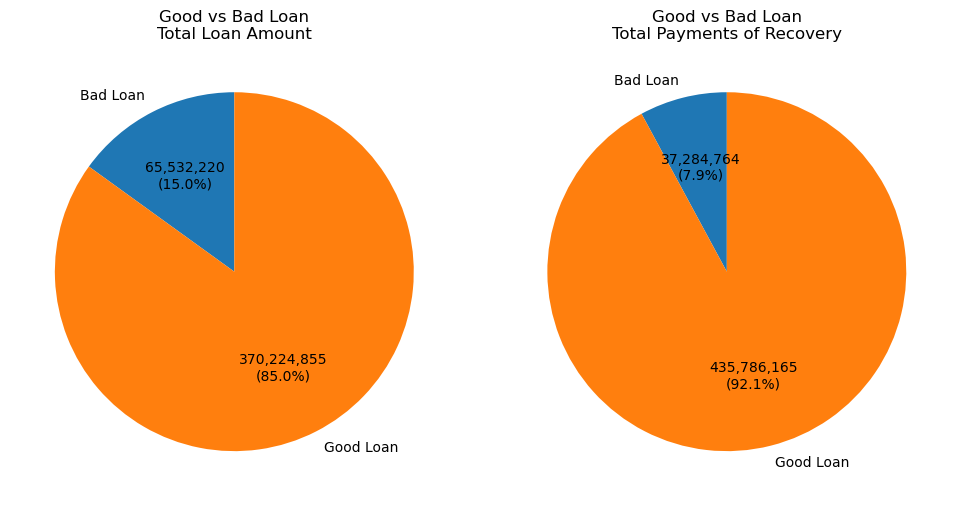

In [78]:
loan_amount_sum = df.groupby('Good vs Bad Loan')['loan_amount'].sum()
total_payment_sum = df.groupby('Good vs Bad Loan')['Total Payment'].sum()
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:,}\n({pct:.1f}%)'
    return my_autopct

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(loan_amount_sum,labels=loan_amount_sum.index, autopct=make_autopct(loan_amount_sum), startangle=90)
plt.title('Good vs Bad Loan\nTotal Loan Amount')
# -------- Pie Chart 2 --------
plt.subplot(1, 2, 2)
plt.pie(total_payment_sum,labels=total_payment_sum.index,autopct=make_autopct(total_payment_sum),startangle=90)
plt.title('Good vs Bad Loan\nTotal Payments of Recovery')
plt.tight_layout()
plt.show()


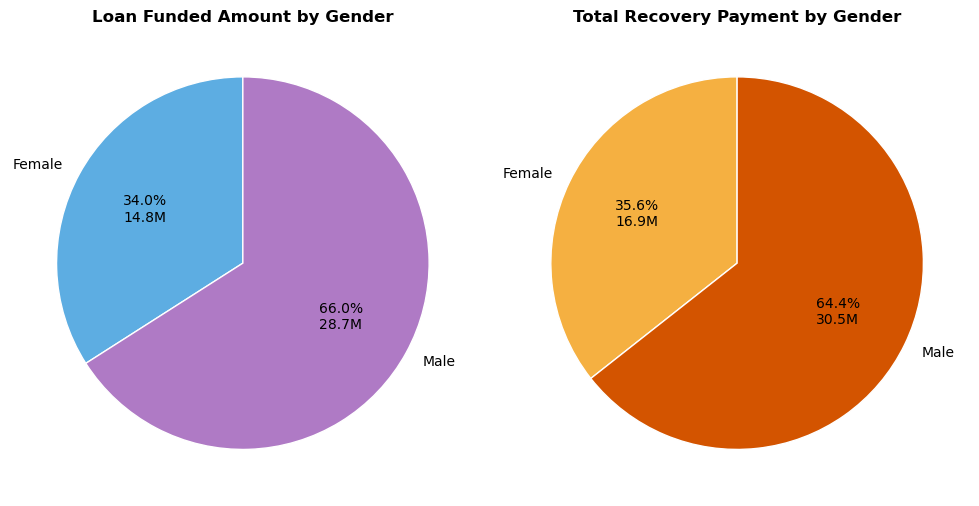

In [135]:
loan_gender = df.groupby('Gender')['loan_amount'].sum()
payment_gender = df.groupby('Gender')['Total Payment'].sum()

# Convert to millions (optional)
loan_gender_millions = loan_gender / 1_000_0000
payment_gender_millions = payment_gender / 1_000_0000

# Create Dashboard
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Pie Chart 1: Loan Amount by Gender
axes[0].pie(
    loan_gender_millions.values,
    labels=loan_gender_millions.index,
    autopct=lambda p: f'{p:.1f}%\n{p*loan_gender_millions.sum()/100:.1f}M',
    startangle=90,
    colors=['#5DADE2', '#AF7AC5'],  # Blue & Purple
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title("Loan Funded Amount by Gender", fontsize=12, fontweight='bold')

# Pie Chart 2: Total Payment by Gender
axes[1].pie(
    payment_gender_millions.values,
    labels=payment_gender_millions.index,
    autopct=lambda p: f'{p:.1f}%\n{p*payment_gender_millions.sum()/100:.1f}M',
    startangle=90,
    colors=['#F5B041', '#D35400'],  # Light Orange & Darker Orange
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title("Total Recovery Payment by Gender", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Regional Analysis by State for Total Funded Loans

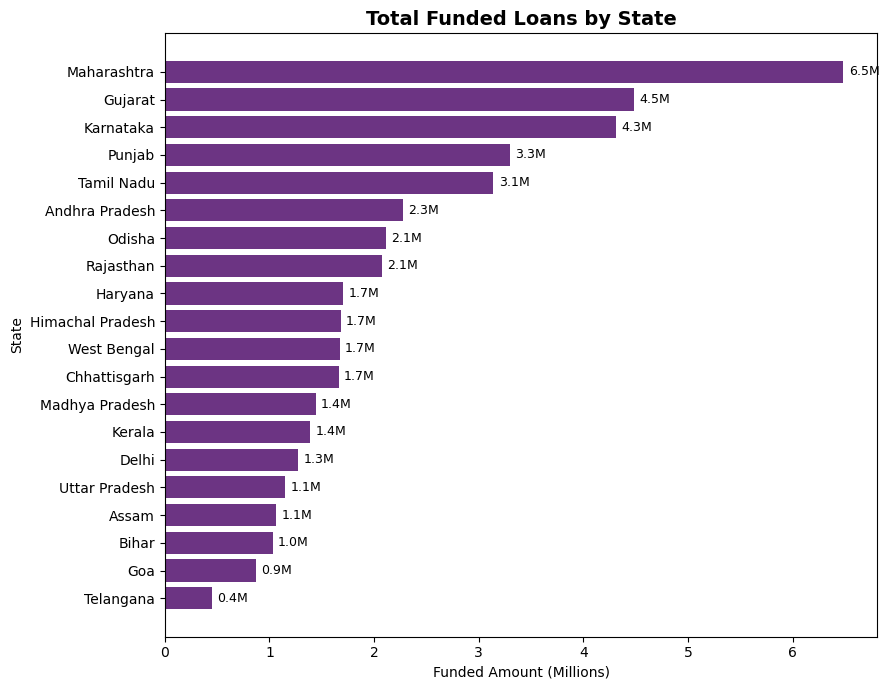

In [85]:
state_funding = df.groupby('State')['loan_amount'].sum().sort_values(ascending=True)
state_funding_millions = state_funding / 10_000_000  # Crores / 10M
plt.figure(figsize=(9, 7))
bars = plt.barh(
    state_funding_millions.index,
    state_funding_millions.values,
    color='#6C3483'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.1f}M',
        va='center',
        fontsize=9
    )

plt.title("Total Funded Loans by State", fontsize=14, fontweight='bold')
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


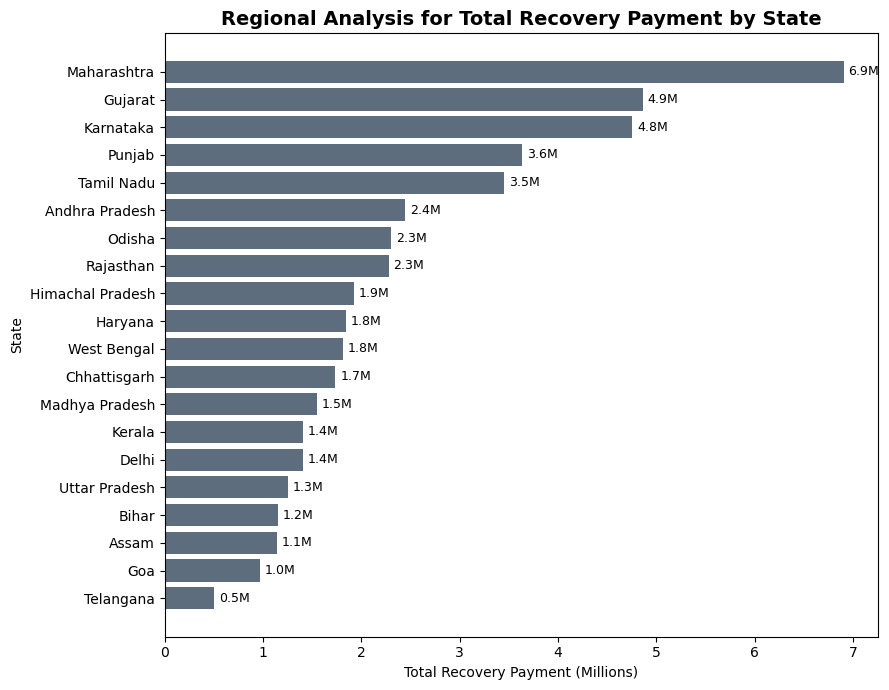

In [89]:
state_recovery = df.groupby('State')['Total Payment'].sum().sort_values(ascending=True)
state_recovery_millions = state_recovery / 10_000_000  # Millions / 10M
plt.figure(figsize=(9, 7))
bars = plt.barh(state_recovery_millions.index,state_recovery_millions.values, color='#5D6D7E')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.1f}M',
        va='center',
        fontsize=9
    )

plt.title("Regional Analysis for Total Recovery Payment by State",fontsize=14,fontweight='bold')
plt.xlabel('Total Recovery Payment (Millions)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


## Long Term Analysis by Total Funded Loans &  Total Funded Amount

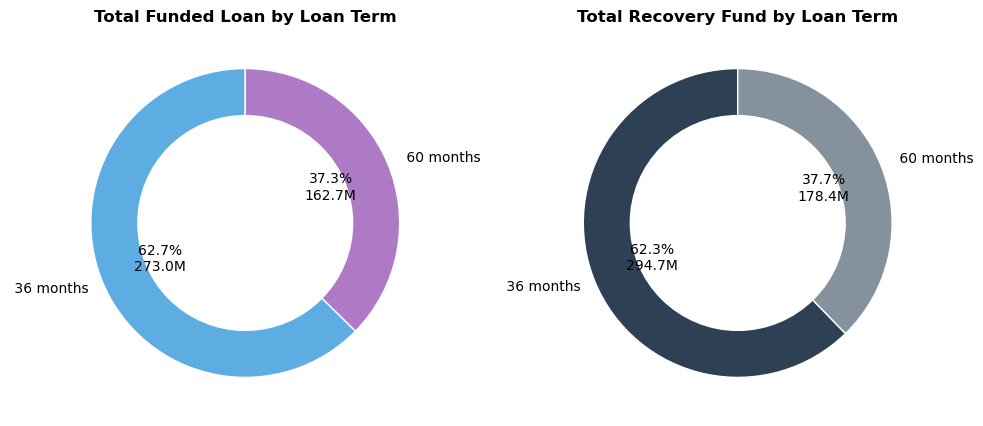

In [136]:
term_funding = df.groupby('term')['loan_amount'].sum()
term_funding_millions = term_funding / 1_000_000
term_recovery = df.groupby('term')['Total Payment'].sum()
term_recovery_millions = term_recovery / 1_000_000
plt.figure(figsize=(10, 6))
# ===== Chart 1: Total Funded Loan =====
plt.subplot(1, 2, 1)
plt.pie(
    term_funding_millions.values,
    labels=term_funding_millions.index,
    autopct=lambda p: f'{p:.1f}%\n{p*term_funding_millions.sum()/100:.1f}M',
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'},
    colors=['#5DADE2', '#AF7AC5']
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Total Funded Loan by Loan Term", fontsize=12, fontweight='bold')

# ===== Chart 2: Total Recovery Fund =====
plt.subplot(1, 2, 2)
plt.pie(
    term_recovery_millions.values,
    labels=term_recovery_millions.index,
    autopct=lambda p: f'{p:.1f}%\n{p*term_recovery_millions.sum()/100:.1f}M',
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'},
    colors=['#2E4053', '#85929E']
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Total Recovery Fund by Loan Term", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


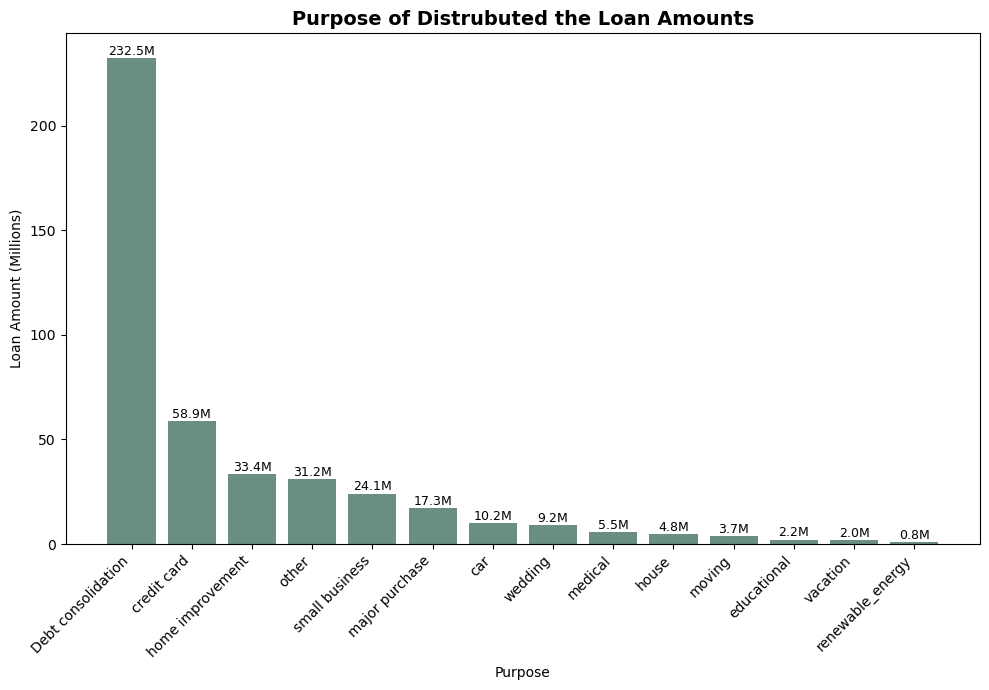

In [115]:
purpose_funding = df.groupby('Purpose')['loan_amount'].sum().sort_values(ascending=False)
purpose_funding_millions = purpose_funding / 1_000_000
plt.figure(figsize=(10, 7))
bars = plt.bar(
    purpose_funding_millions.index,
    purpose_funding_millions.values,
    color='#6A8E7F'
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height:,.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Purpose of Distrubuted the Loan Amounts", fontsize=14, fontweight='bold')
plt.xlabel("Purpose")
plt.ylabel("Loan Amount (Millions)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


### Loan Amount Distributed by Region

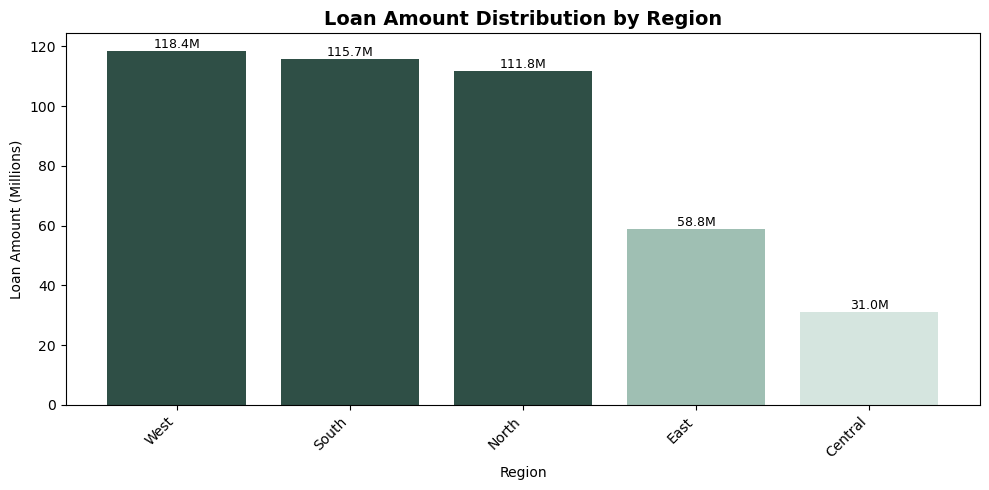

In [118]:
region_funding = df.groupby('Region')['loan_amount'].sum().sort_values(ascending=False)
region_funding_millions = region_funding / 1_000_000

plt.figure(figsize=(10, 5))

# ---- Darker green gradient (single color family) ----
dark_green_colors = ['#D5E5DF', '#9FBFB3', '#6A8E7F', '#4F6F64', '#2F4F46']
cmap = LinearSegmentedColormap.from_list(
    "dark_green_gradient",
    dark_green_colors,
    N=len(region_funding_millions)
)

norm = plt.Normalize(
    region_funding_millions.min(),
    region_funding_millions.max()
)
colors = cmap(norm(region_funding_millions.values))

bars = plt.bar(
    region_funding_millions.index,
    region_funding_millions.values,
    color=colors
)

# Data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height:,.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Loan Amount Distribution by Region", fontsize=14, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Loan Amount (Millions)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Most Loan Funded by Issued Date

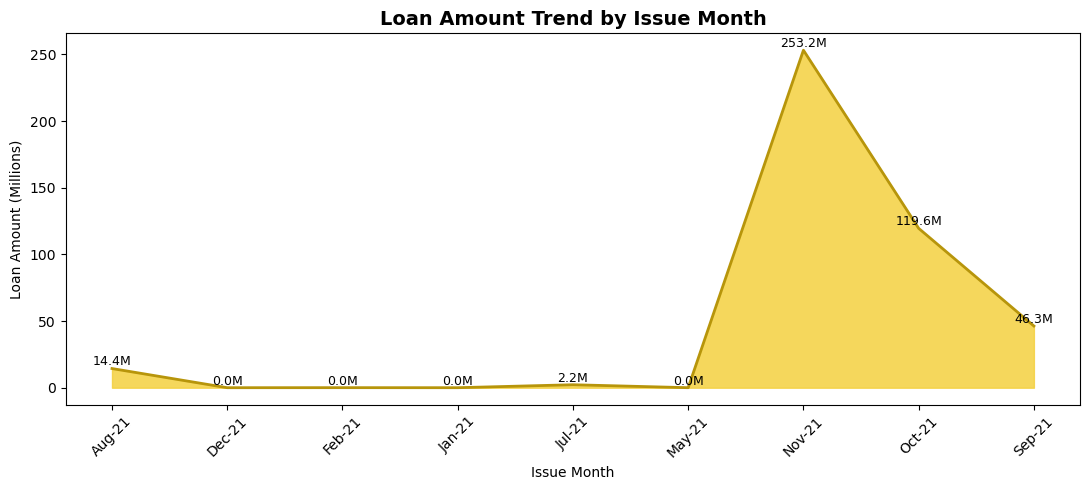

In [125]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['Issue_Month'] = df['issue_date'].dt.strftime('%b-%y')
monthly_funding = df.groupby('Issue_Month')['loan_amount'].sum()
monthly_funding_millions = monthly_funding / 1_000_000

plt.figure(figsize=(11, 5))

# Area Chart
plt.fill_between(
    monthly_funding_millions.index,
    monthly_funding_millions.values,
    color='#F4D03F',
    alpha=0.85
)

plt.plot(
    monthly_funding_millions.index,
    monthly_funding_millions.values,
    color='#B7950B',
    linewidth=2
)

# Data labels
for x, y in zip(monthly_funding_millions.index, monthly_funding_millions.values):
    plt.text(
        x,
        y + 0.05,
        f'{y:,.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Loan Amount Trend by Issue Month", fontsize=14, fontweight='bold')
plt.xlabel("Issue Month")
plt.ylabel("Loan Amount (Millions)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Total Recovery Fund by Last Credit Pull Date

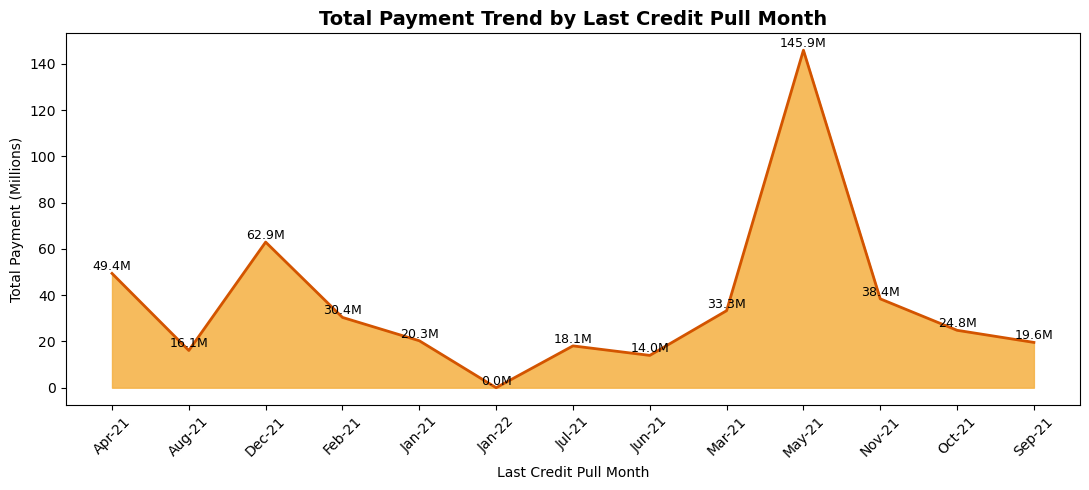

In [131]:
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'])

# Create Month-Year format (e.g., Oct-21)
df['Issue_Month'] = df['last_credit_pull_date'].dt.strftime('%b-%y')

# Group & convert to millions
monthly_payment = df.groupby('Issue_Month')['Total Payment'].sum()
monthly_payment_millions = monthly_payment / 1_000_000

plt.figure(figsize=(11, 5))

# Area Chart (Light Orange)
plt.fill_between(
    monthly_payment_millions.index,
    monthly_payment_millions.values,
    color='#F5B041',   # Light Orange
    alpha=0.85
)

plt.plot(
    monthly_payment_millions.index,
    monthly_payment_millions.values,
    color='#D35400',   # Darker Orange line
    linewidth=2
)

# Data labels
for x, y in zip(monthly_payment_millions.index, monthly_payment_millions.values):
    plt.text(
        x,
        y + 0.05,
        f'{y:,.1f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Total Payment Trend by Last Credit Pull Month", fontsize=14, fontweight='bold')
plt.xlabel("Last Credit Pull Month")
plt.ylabel("Total Payment (Millions)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Conclusion

### This Bank Loan Analysis project provides a clear overview of total funded amounts, recoveries, interest rates, and borrower risk metrics like DTI. The analysis highlights strong performance from Good Loans (Fully Paid & Current) with higher recovery and lower risk, while Bad Loans (Charged Off) contribute limited recovery. Overall, the insights support better credit decision-making and portfolio risk management.